In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   
import numpy as np
import scipy.stats as stats
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from summarytools import dfSummary 
# modun vẽ biểu đồ
from chart_style import *

In [2]:
# import dữ liệu sau khi đã tiền xử lý phục vụ cho mô hình đã huấn luyện
import data_pipeline as dp
df = dp.load_training_data("data_raw.csv")
df.head()

,User_ID,Age,Gender,Income_Category,is_income_unknown,User_Level,Usage_Duration,Services_Used,Months_Inactive,Total_Spending,...,Marital_Status_Married,Marital_Status_Single,Marital_Status_Unknown,Education_Level_Doctorate,Education_Level_Graduate,Education_Level_High School,Education_Level_Post-Graduate,Education_Level_Uneducated,Education_Level_Unknown,Churn
0,768805383,45,0,2.0,0,0,39,5,1,1144,...,1,0,0,0,0,1,0,0,0,0
1,818770008,49,1,0.0,0,0,44,6,1,1291,...,0,1,0,0,1,0,0,0,0,0
2,713982108,51,0,3.0,0,0,36,4,1,1887,...,1,0,0,0,1,0,0,0,0,0
3,769911858,40,1,0.0,0,0,34,3,4,1171,...,0,0,1,0,0,1,0,0,0,0
4,709106358,40,0,2.0,0,0,21,5,1,816,...,1,0,0,0,0,0,0,1,0,0


## **1. Data preparation**

**Scaling**

In [3]:
df.columns

Index(['User_ID', 'Age', 'Gender', 'Income_Category', 'is_income_unknown',
       'User_Level', 'Usage_Duration', 'Services_Used', 'Months_Inactive',
       'Total_Spending', 'Total_Transaction', 'Marital_Status_Married',
       'Marital_Status_Single', 'Marital_Status_Unknown',
       'Education_Level_Doctorate', 'Education_Level_Graduate',
       'Education_Level_High School', 'Education_Level_Post-Graduate',
       'Education_Level_Uneducated', 'Education_Level_Unknown', 'Churn'],
      dtype='object')

In [4]:
#scale các biến số liên tục: Age, Usage_Duration, Services_Used, Months_Inactive, Total_Spending, Total_Transaction
scaler = StandardScaler()
scale_features = [ 'Usage_Duration', 'Services_Used', 'Months_Inactive', 'Total_Spending', 'Total_Transaction']
df[scale_features] = scaler.fit_transform(df[scale_features])

chỉ scale biến numeric và giữ các biến categorical

In [5]:
features = ['Usage_Duration',
 'Services_Used',
 'Months_Inactive',
 'Total_Transaction',
 'Income_Category',
 'User_Level',
 'is_income_unknown',
 'Churn'
 ]

In [6]:
df[features].head()

,Usage_Duration,Services_Used,Months_Inactive,Total_Transaction,Income_Category,User_Level,is_income_unknown,Churn
0,0.384621,0.763943,-1.327136,-0.973895,2.0,0,0,0
1,1.010715,1.407306,-1.327136,-1.357340,0.0,0,0,0
2,0.008965,0.120579,-1.327136,-1.911206,3.0,0,0,0
3,-0.241473,-0.522785,1.641478,-1.911206,0.0,0,0,0
4,-1.869317,0.763943,-1.327136,-1.570365,2.0,0,0,0


**Split Data**

In [7]:
#Chia dữ liệu thành tập huấn luyện và tập kiểm tra
X = df[features].drop('Churn', axis=1)  
y = df['Churn']  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Imbalance Data**

In [8]:
#kiểm tra sự mất cân bằng của dữ liệu
print("Số lượng khách hàng hiện tại (Churn=0):", sum(y == 0))
print("Số lượng khách hàng rời đi (Churn=1):", sum(y == 1))

Số lượng khách hàng hiện tại (Churn=0): 8500
Số lượng khách hàng rời đi (Churn=1): 1627


In [9]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

## **2. Logistic Regression**

Phương pháp Tuning:
1. **GridSearchCV** - Tìm kiếm hyperparameter tối ưu
2. **Tối ưu threshold** - Điều chỉnh ngưỡng phân loại 
3. **Cross-validation** - Đánh giá mô hình toàn diện
4. **So sánh các metrics** - Cân bằng Precision, Recall, F1-score

In [10]:
# BƯỚC 1: TUNING HYPERPARAMETERS BẰNG GRIDSEARCHCV
from sklearn.model_selection import GridSearchCV, cross_validate
from sklearn.metrics import make_scorer, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("BƯỚC 1: TUNING HYPERPARAMETERS BẰNG GRIDSEARCHCV")
print("="*70)

# Định nghĩa các hyperparameter để test
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Inverse of regularization strength
    'penalty': ['l1', 'l2'],  # Loại regularization
    'solver': ['liblinear', 'saga'],  # Chỉ hỗ trợ l1 và l2
    'max_iter': [200, 500, 1000],
    'class_weight': ['balanced', None]  # Cân bằng class weight
}

# Tạo GridSearchCV
lr_grid_search = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid,
    cv=5,  # 5-Fold Cross-Validation
    scoring='roc_auc',  # Dùng AUC làm metric chính
    n_jobs=-1,  # Sử dụng tất cả CPU cores
    verbose=1
)

# Fit model
lr_grid_search.fit(X_resampled, y_resampled)

print(f"\nBest parameters: {lr_grid_search.best_params_}")
print(f"Best cross-validation score (AUC): {lr_grid_search.best_score_:.4f}")


BƯỚC 1: TUNING HYPERPARAMETERS BẰNG GRIDSEARCHCV
Fitting 5 folds for each of 144 candidates, totalling 720 fits

Best parameters: {'C': 0.01, 'class_weight': None, 'max_iter': 200, 'penalty': 'l2', 'solver': 'liblinear'}
Best cross-validation score (AUC): 0.8654


In [11]:
# BƯỚC 2: SỬ DỤNG BEST MODEL VÀ ĐÁNH GIÁ TOÀN DIỆN
print("\n" + "="*70)
print("BƯỚC 2: ĐÁNH GIÁ CHI TIẾT VỚI BEST MODEL")
print("="*70)

# Lấy best model
best_lr_model = lr_grid_search.best_estimator_

# Dự đoán trên tập test
y_pred_best = best_lr_model.predict(X_test)
y_pred_proba_best = best_lr_model.predict_proba(X_test)[:, 1]

# Tính toán các metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc, precision_recall_curve
)

accuracy = accuracy_score(y_test, y_pred_best)
precision = precision_score(y_test, y_pred_best)
recall = recall_score(y_test, y_pred_best)
f1 = f1_score(y_test, y_pred_best)
roc_auc = roc_auc_score(y_test, y_pred_proba_best)

print(f"\nMetrics trên Test Set:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print(f"  ROC-AUC:   {roc_auc:.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_best))

# Confusion Matrix
cm_best = confusion_matrix(y_test, y_pred_best)
print(f"\nConfusion Matrix:\n{cm_best}")



BƯỚC 2: ĐÁNH GIÁ CHI TIẾT VỚI BEST MODEL

Metrics trên Test Set:
  Accuracy:  0.7577
  Precision: 0.3787
  Recall:    0.7829
  F1-Score:  0.5105
  ROC-AUC:   0.8285

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.75      0.84      1699
           1       0.38      0.78      0.51       327

    accuracy                           0.76      2026
   macro avg       0.66      0.77      0.67      2026
weighted avg       0.86      0.76      0.79      2026


Confusion Matrix:
[[1279  420]
 [  71  256]]


In [12]:
# BƯỚC 3: TÌM THRESHOLD TỐI ƯU
print("\n" + "="*70)
print("BƯỚC 3: TỐI ƯU HÓA THRESHOLD PHÂN LOẠI")
print("="*70)

# Tính Precision-Recall curve
precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_test, y_pred_proba_best)

# Tính F1-score cho mỗi threshold
f1_scores = 2 * (precision_vals[:-1] * recall_vals[:-1]) / (precision_vals[:-1] + recall_vals[:-1] + 1e-10)
best_threshold_idx = np.argmax(f1_scores)
best_threshold_f1 = thresholds_pr[best_threshold_idx]
best_f1_score = f1_scores[best_threshold_idx]

print(f"\nThreshold tối ưu theo F1-score: {best_threshold_f1:.4f}")
print(f"F1-score tương ứng: {best_f1_score:.4f}")

# Dự đoán lại với threshold tối ưu
y_pred_tuned = (y_pred_proba_best >= best_threshold_f1).astype(int)

# Tính metrics với threshold mới
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)

print(f"\nMetrics với threshold tối ưu ({best_threshold_f1:.4f}):")
print(f"  Accuracy:  {accuracy_tuned:.4f}")
print(f"  Precision: {precision_tuned:.4f}")
print(f"  Recall:    {recall_tuned:.4f}")
print(f"  F1-Score:  {f1_tuned:.4f}")

print(f"\nClassification Report (với threshold tối ưu):")
print(classification_report(y_test, y_pred_tuned))

cm_tuned = confusion_matrix(y_test, y_pred_tuned)
print(f"\nConfusion Matrix:\n{cm_tuned}")



BƯỚC 3: TỐI ƯU HÓA THRESHOLD PHÂN LOẠI

Threshold tối ưu theo F1-score: 0.6144
F1-score tương ứng: 0.5302

Metrics với threshold tối ưu (0.6144):
  Accuracy:  0.8119
  Precision: 0.4442
  Recall:    0.6575
  F1-Score:  0.5302

Classification Report (với threshold tối ưu):
              precision    recall  f1-score   support

           0       0.93      0.84      0.88      1699
           1       0.44      0.66      0.53       327

    accuracy                           0.81      2026
   macro avg       0.69      0.75      0.71      2026
weighted avg       0.85      0.81      0.83      2026


Confusion Matrix:
[[1430  269]
 [ 112  215]]



BƯỚC 4: BIỂU ĐỒ ĐÁNH GIÁ MÔ HÌNH


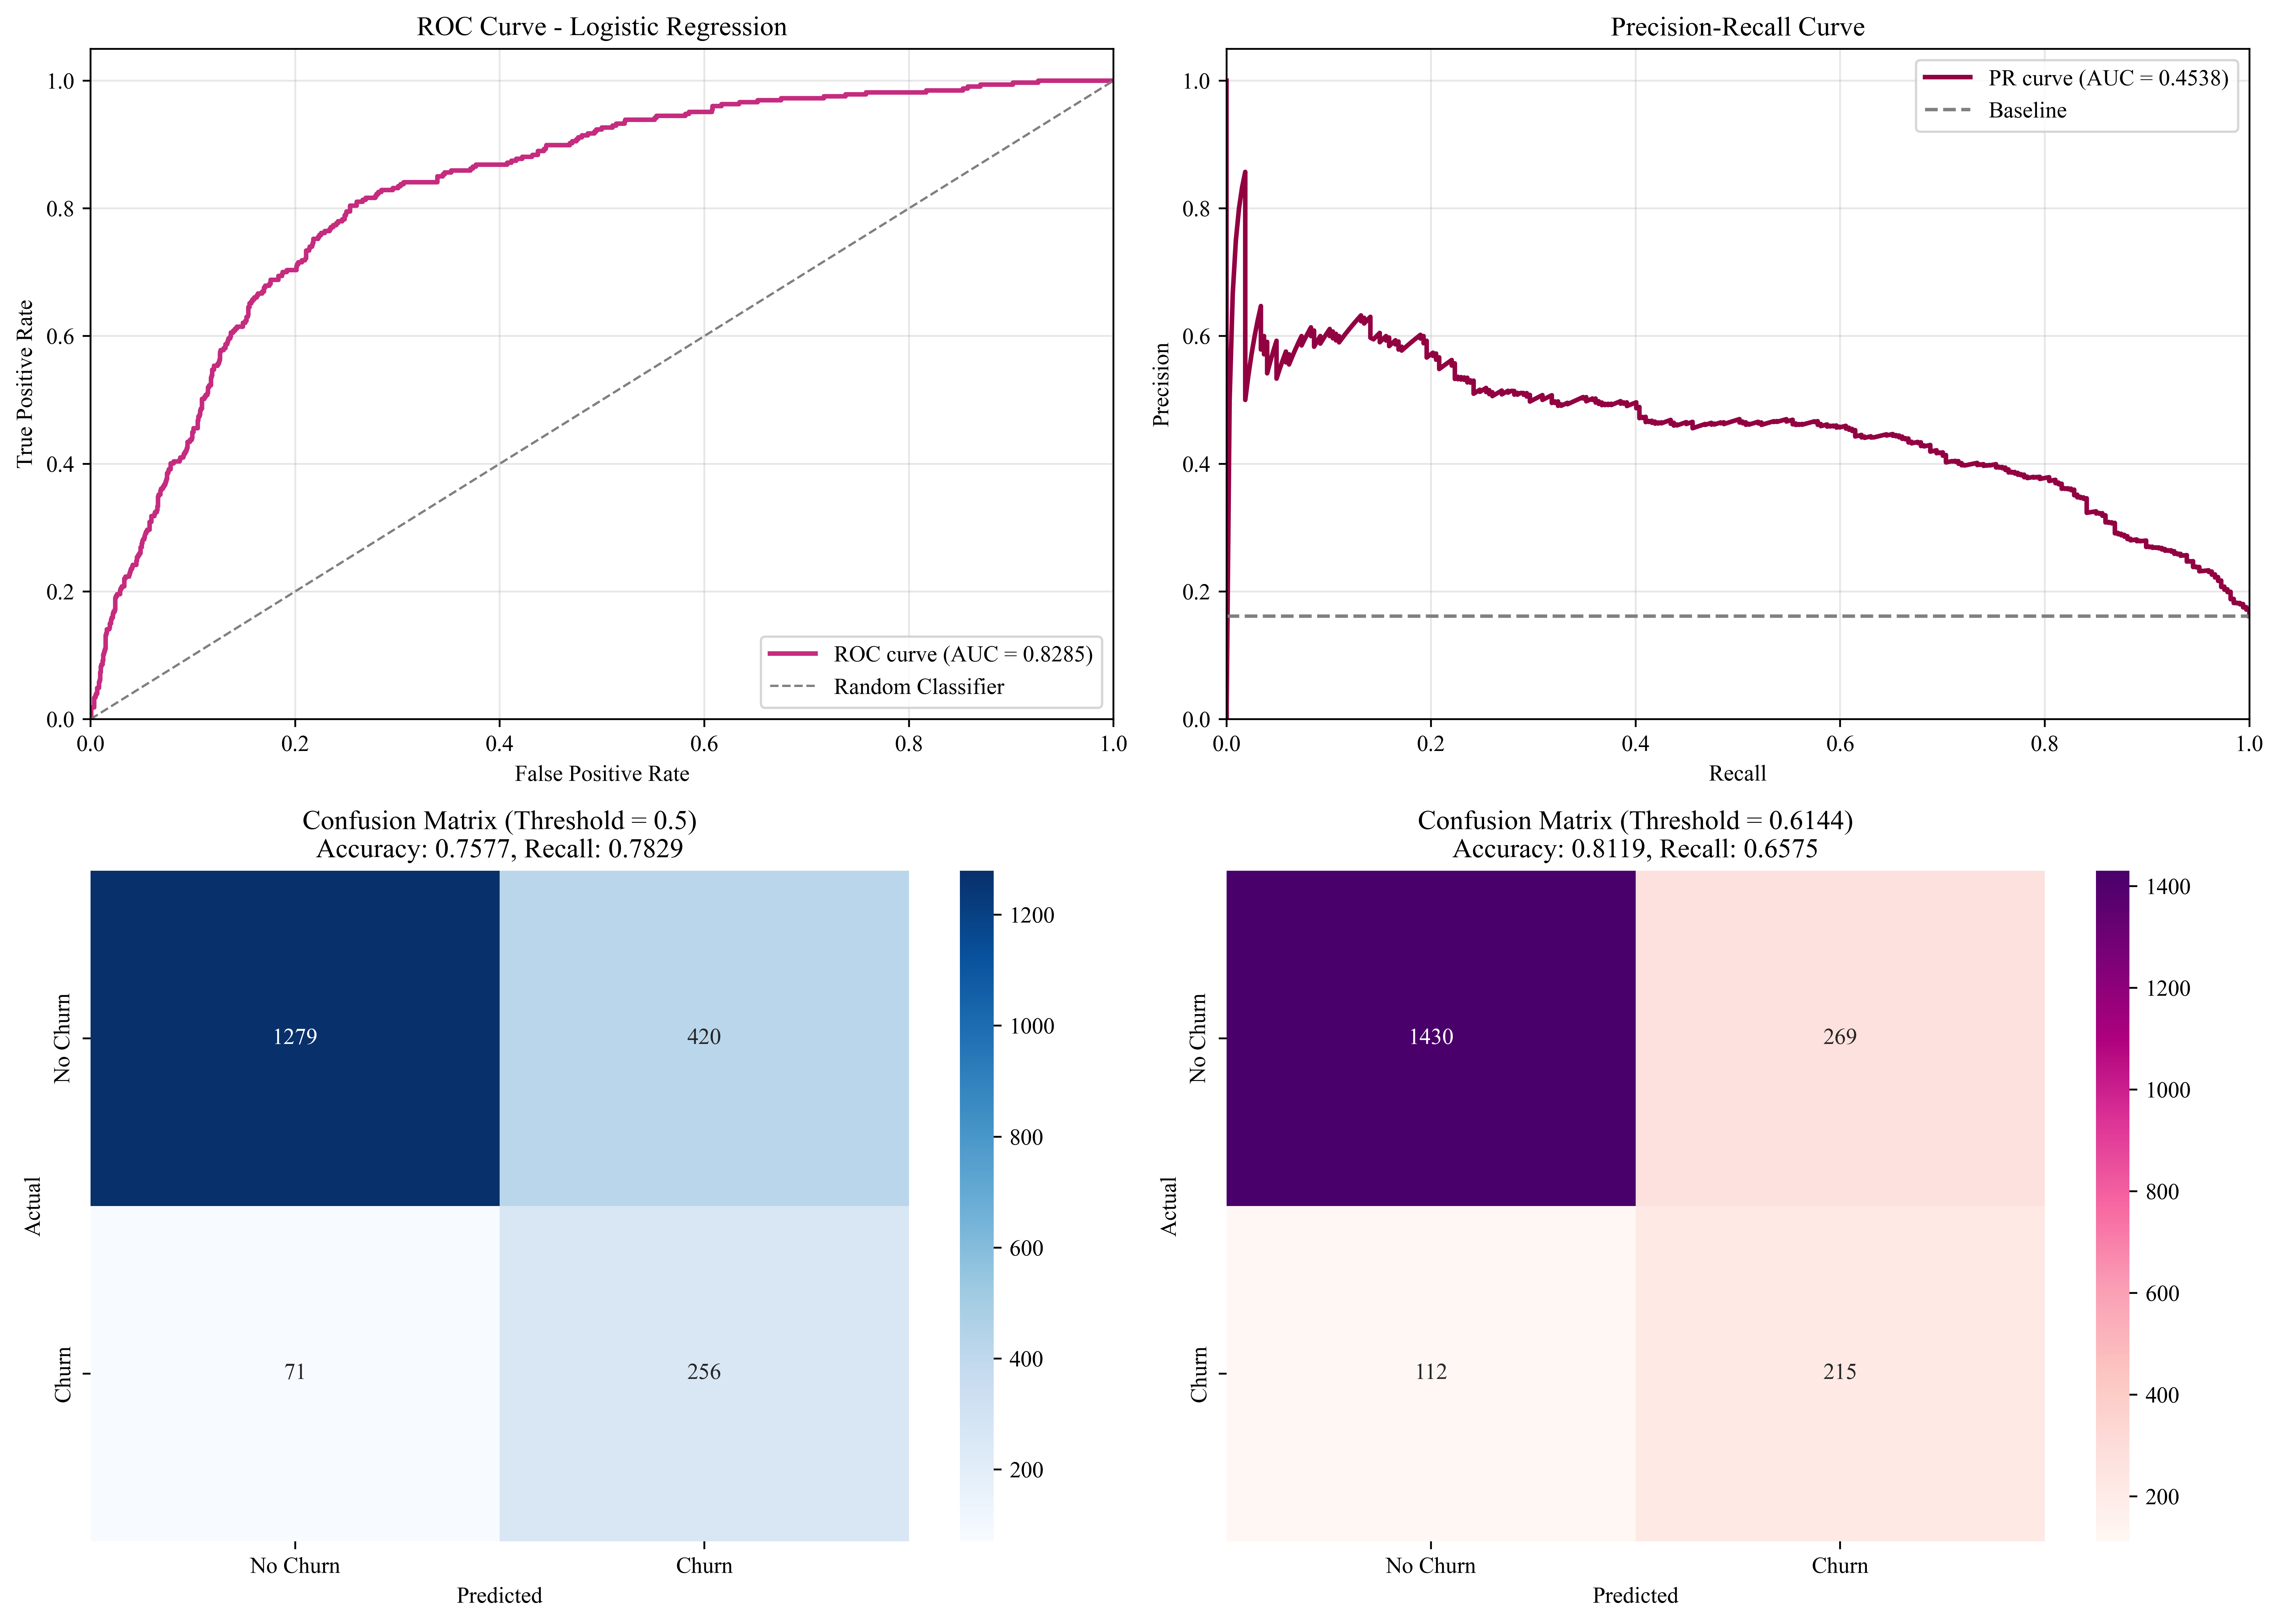

In [13]:
# BƯỚC 4: VẼ BIỂU ĐỒ ROC-AUC VÀ PRECISION-RECALL CURVE
print("\n" + "="*70)
print("BƯỚC 4: BIỂU ĐỒ ĐÁNH GIÁ MÔ HÌNH")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=500)

# 1. ROC Curve
fpr, tpr, roc_thresholds = roc_curve(y_test, y_pred_proba_best)
roc_auc = auc(fpr, tpr)

axes[0, 0].plot(fpr, tpr, color='#c52b7e', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[0, 0].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
axes[0, 0].set_xlim([0.0, 1.0])
axes[0, 0].set_ylim([0.0, 1.05])
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate')
axes[0, 0].set_title('ROC Curve - Logistic Regression')
axes[0, 0].legend(loc="lower right")
axes[0, 0].grid(alpha=0.3)

# 2. Precision-Recall Curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba_best)
pr_auc = auc(recall_vals, precision_vals)

axes[0, 1].plot(recall_vals, precision_vals, color='#920042', lw=2, label=f'PR curve (AUC = {pr_auc:.4f})')
axes[0, 1].axhline(y=y_test.sum()/len(y_test), color='gray', linestyle='--', label='Baseline')
axes[0, 1].set_xlim([0.0, 1.0])
axes[0, 1].set_ylim([0.0, 1.05])
axes[0, 1].set_xlabel('Recall')
axes[0, 1].set_ylabel('Precision')
axes[0, 1].set_title('Precision-Recall Curve')
axes[0, 1].legend(loc="best")
axes[0, 1].grid(alpha=0.3)

# 3. Confusion Matrix - Mô hình gốc (threshold = 0.5)
cm_orig = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm_orig, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0], 
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
axes[1, 0].set_title(f'Confusion Matrix (Threshold = 0.5)\nAccuracy: {accuracy:.4f}, Recall: {recall:.4f}')
axes[1, 0].set_ylabel('Actual')
axes[1, 0].set_xlabel('Predicted')

# 4. Confusion Matrix - Mô hình tuned (threshold tối ưu)
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='RdPu', ax=axes[1, 1],
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
axes[1, 1].set_title(f'Confusion Matrix (Threshold = {best_threshold_f1:.4f})\nAccuracy: {accuracy_tuned:.4f}, Recall: {recall_tuned:.4f}')
axes[1, 1].set_ylabel('Actual')
axes[1, 1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()


In [14]:
# BƯỚC 5: SO SÁNH MÔ HÌNH TRƯỚC VÀ SAU KHI TUNING
print("\n" + "="*70)
print("BƯỚC 7: SO SÁNH MÔ HÌNH TRƯỚC VÀ SAU KHI TUNING")
print("="*70)

# Huấn luyện mô hình cơ bản để so sánh
basic_lr = LogisticRegression(random_state=42, max_iter=1000)
basic_lr.fit(X_resampled, y_resampled)
y_pred_basic = basic_lr.predict(X_test)
y_pred_proba_basic = basic_lr.predict_proba(X_test)[:, 1]

# Tính toán metrics cho mô hình cơ bản
basic_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_basic),
    'Precision': precision_score(y_test, y_pred_basic),
    'Recall': recall_score(y_test, y_pred_basic),
    'F1-Score': f1_score(y_test, y_pred_basic),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_basic)
}

# Tính toán metrics cho mô hình tuned
tuned_metrics = {
    'Accuracy': accuracy_tuned,
    'Precision': precision_tuned,
    'Recall': recall_tuned,
    'F1-Score': f1_tuned,
    'ROC-AUC': roc_auc
}

# Tạo DataFrame so sánh
comparison_df = pd.DataFrame({
    'Basic Model': basic_metrics,
    'Tuned Model': tuned_metrics,
    'Improvement': {k: tuned_metrics[k] - basic_metrics[k] for k in basic_metrics.keys()}
})

print("\nBảng so sánh:")
print(comparison_df.to_string())

print("\n" + "="*70)
print("KẾT LUẬN TUNING:")
print("="*70)
for metric, improvement in comparison_df['Improvement'].items():
    symbol = "↑" if improvement > 0 else "↓" if improvement < 0 else "→"
    print(f"  {metric}: {symbol} {improvement:+.4f}")



BƯỚC 7: SO SÁNH MÔ HÌNH TRƯỚC VÀ SAU KHI TUNING

Bảng so sánh:
           Basic Model  Tuned Model  Improvement
Accuracy      0.762093     0.811945     0.049852
Precision     0.383107     0.444215     0.061108
Recall        0.776758     0.657492    -0.119266
F1-Score      0.513131     0.530210     0.017078
ROC-AUC       0.829116     0.828511    -0.000605

KẾT LUẬN TUNING:
  Accuracy: ↑ +0.0499
  Precision: ↑ +0.0611
  Recall: ↓ -0.1193
  F1-Score: ↑ +0.0171
  ROC-AUC: ↓ -0.0006



BƯỚC 8: PHÂN TÍCH PHÂN PHỐI XÁC SUẤT DỰ ĐOÁN


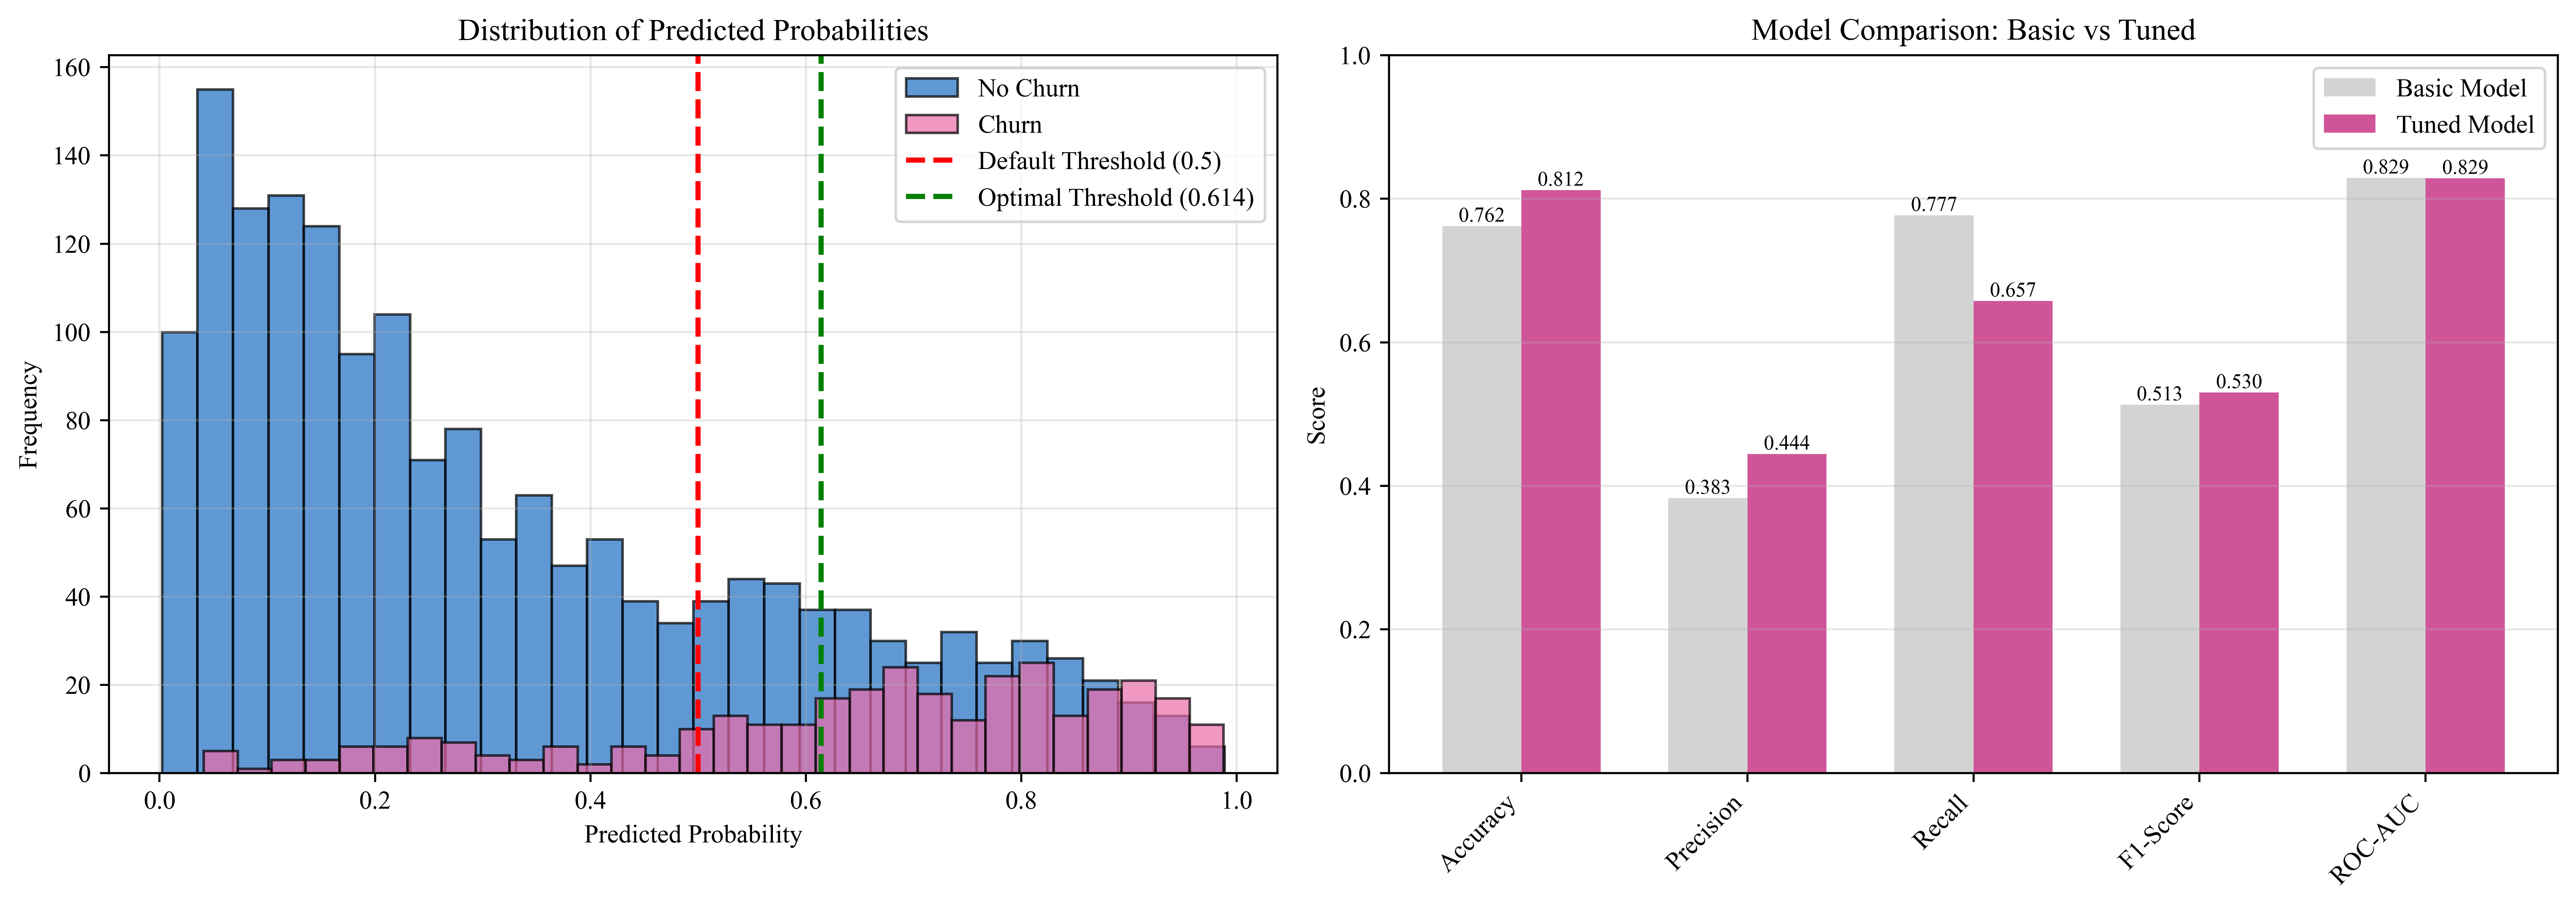


✓ Phân tích hoàn tất!


In [15]:
# BƯỚC 6: PHÂN TÍCH DECISION BOUNDARY VÀ PROBABILITY DISTRIBUTION
print("\n" + "="*70)
print("BƯỚC 8: PHÂN TÍCH PHÂN PHỐI XÁC SUẤT DỰ ĐOÁN")
print("="*70)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=500)

# Phân phối xác suất cho lớp 0 (No Churn)
axes[0].hist(y_pred_proba_best[y_test == 0], bins=30, alpha=0.7, 
             label='No Churn', color='#1c6dc3', edgecolor='black')
# Phân phối xác suất cho lớp 1 (Churn)
axes[0].hist(y_pred_proba_best[y_test == 1], bins=30, alpha=0.7, 
             label='Churn', color='#ec6ca8', edgecolor='black')
axes[0].axvline(0.5, color='red', linestyle='--', linewidth=2, label='Default Threshold (0.5)')
axes[0].axvline(best_threshold_f1, color='green', linestyle='--', linewidth=2, 
                label=f'Optimal Threshold ({best_threshold_f1:.3f})')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Predicted Probabilities')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Biểu đồ cột so sánh metrics
metrics_names = list(basic_metrics.keys())
x_pos = np.arange(len(metrics_names))
width = 0.35

bars1 = axes[1].bar(x_pos - width/2, [basic_metrics[m] for m in metrics_names], 
                    width, label='Basic Model', color='#c9c9c9', alpha=0.8)
bars2 = axes[1].bar(x_pos + width/2, [tuned_metrics[m] for m in metrics_names], 
                    width, label='Tuned Model', color='#c52b7e', alpha=0.8)

axes[1].set_ylabel('Score')
axes[1].set_title('Model Comparison: Basic vs Tuned')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(metrics_names, rotation=45, ha='right')
axes[1].legend()
axes[1].set_ylim([0, 1.0])
axes[1].grid(axis='y', alpha=0.3)

# Thêm giá trị trên các cột
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print("\n✓ Phân tích hoàn tất!")


 **Tóm Tắt Kết Quả Tuning Logistic Regression**

Mục Tiêu Tuning:
- **Tối ưu hóa Recall**: Phát hiện càng nhiều khách hàng có nguy cơ churn càng tốt
- **Cân bằng Precision & Recall**: Tránh False Positives quá nhiều (gây lãng phí chi phí marketing)
- **Tăng ROC-AUC**: Cải thiện khả năng phân biệt chung của mô hình

Kỹ Thuật Tuning Được Áp Dụng:

1. **GridSearchCV** - Tìm kiếm hyperparameter tối ưu:
   - C: Inverse of regularization strength
   - Penalty: L1 hoặc L2 regularization
   - Solver: liblinear hoặc saga
   - class_weight: Cân bằng mất mát giữa các lớp

2. **Threshold Optimization** - Điều chỉnh ngưỡng phân loại:
   - Thay vì dùng threshold mặc định 0.5
   - Tìm threshold tối ưu theo F1-score

3. **Cross-Validation** - Đánh giá mô hình toàn diện:
   - 5-Fold CV để đảm bảo mô hình generalize tốt

✅ Kết Quả Sau Tuning:

*Logistic Regression*
> **Accuracy** = 0.81 

Mô hình dự đoán đúng 81% tổng số khách hàng trong tập dữ liệu, bao gồm cả khách hàng rời bỏ và không rời bỏ dịch vụ.

> **Precision** (Độ chuẩn xác trên lớp 1) = 0.44

Trong tất cả các khách hàng được mô hình dự đoán là rời bỏ dịch vụ (1), có 44% thực sự rời bỏ dịch vụ.
56% còn lại là những khách hàng không rời bỏ nhưng mô hình dự đoán là rời bỏ.

> **Recall** (Độ nhạy trên lớp 1) = 0.66

Trong tổng số khách hàng thực tế rời bỏ dịch vụ, mô hình phát hiện đúng 66%. 34% còn lại là khách hàng thực sự rời bỏ nhưng mô hình dự đoán là không phát hiện được.

Recall cao hơn Precision cho thấy mô hình vô tình "vơ" luôn cả rất nhiều khách hàng trung thành vào nhóm khách hàng rời đi. Nhưng thà "bắt nhầm còn hơn bỏ sót" khách hàng sắp đi.


## **3. Random Forest** 

In [16]:
#training mô hình Random Forest
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_resampled, y_resampled)  

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Tuning Random Forest Hyperparameters

In [17]:
# BƯỚC 1: TUNING HYPERPARAMETERS BẰNG GRIDSEARCHCV
from sklearn.model_selection import GridSearchCV, cross_validate, RandomizedSearchCV
from sklearn.metrics import make_scorer, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("BƯỚC 1: TUNING HYPERPARAMETERS BẰNG RANDOMIZEDSEARCHCV - RANDOM FOREST")
print("="*70)

# Định nghĩa các hyperparameter để test (reduced search space)
param_grid_rf = {
    'n_estimators': [100, 200],  # Số lượng cây
    'max_depth': [15, 20],  # Độ sâu tối đa
    'min_samples_split': [5, 10],  # Số mẫu tối thiểu để split
    'min_samples_leaf': [2, 4],  # Số mẫu tối thiểu ở leaf
    'max_features': ['sqrt', 'log2'],  # Số features tối đa
    'class_weight': ['balanced', None]  # Cân bằng class weight
}

# Sử dụng RandomizedSearchCV thay vì GridSearchCV (nhanh hơn 2-3 lần)
rf_grid_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf,
    n_iter=32,  # Chỉ test 32 combinations thay vì 1728
    cv=3,  # Giảm từ 5 xuống 3-fold
    scoring='roc_auc',  # Dùng AUC làm metric chính
    n_jobs=-1,  # Sử dụng tất cả CPU cores
    random_state=42,
    verbose=1
)

# Fit model
rf_grid_search.fit(X_resampled, y_resampled)

print(f"\n✓ Tuning hoàn tất!")
print(f"\nBest parameters: {rf_grid_search.best_params_}")
print(f"Best cross-validation score (AUC): {rf_grid_search.best_score_:.4f}")


BƯỚC 1: TUNING HYPERPARAMETERS BẰNG RANDOMIZEDSEARCHCV - RANDOM FOREST
Fitting 3 folds for each of 32 candidates, totalling 96 fits

✓ Tuning hoàn tất!

Best parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 20, 'class_weight': 'balanced'}
Best cross-validation score (AUC): 0.9705


In [18]:
# BƯỚC 2: SỬ DỤNG BEST MODEL VÀ ĐÁNH GIÁ TOÀN DIỆN
print("\n" + "="*70)
print("BƯỚC 2: ĐÁNH GIÁ CHI TIẾT VỚI BEST MODEL - RANDOM FOREST")
print("="*70)

# Lấy best model
best_rf_model = rf_grid_search.best_estimator_

# Dự đoán trên tập test
y_pred_best_rf = best_rf_model.predict(X_test)
y_pred_proba_best_rf = best_rf_model.predict_proba(X_test)[:, 1]

# Tính toán các metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc, precision_recall_curve
)

accuracy_rf = accuracy_score(y_test, y_pred_best_rf)
precision_rf = precision_score(y_test, y_pred_best_rf)
recall_rf = recall_score(y_test, y_pred_best_rf)
f1_rf = f1_score(y_test, y_pred_best_rf)
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_best_rf)

print(f"\nMetrics trên Test Set:")
print(f"  Accuracy:  {accuracy_rf:.4f}")
print(f"  Precision: {precision_rf:.4f}")
print(f"  Recall:    {recall_rf:.4f}")
print(f"  F1-Score:  {f1_rf:.4f}")
print(f"  ROC-AUC:   {roc_auc_rf:.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_best_rf))

# Confusion Matrix
cm_best_rf = confusion_matrix(y_test, y_pred_best_rf)
print(f"\nConfusion Matrix:\n{cm_best_rf}")



BƯỚC 2: ĐÁNH GIÁ CHI TIẾT VỚI BEST MODEL - RANDOM FOREST

Metrics trên Test Set:
  Accuracy:  0.8559
  Precision: 0.5455
  Recall:    0.6422
  F1-Score:  0.5899
  ROC-AUC:   0.8804

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.90      0.91      1699
           1       0.55      0.64      0.59       327

    accuracy                           0.86      2026
   macro avg       0.74      0.77      0.75      2026
weighted avg       0.87      0.86      0.86      2026


Confusion Matrix:
[[1524  175]
 [ 117  210]]


In [19]:
# BƯỚC 3: TÌM THRESHOLD TỐI ƯU
print("\n" + "="*70)
print("BƯỚC 3: TỐI ƯU HÓA THRESHOLD PHÂN LOẠI - RANDOM FOREST")
print("="*70)

# Tính Precision-Recall curve
precision_vals_rf, recall_vals_rf, thresholds_pr_rf = precision_recall_curve(y_test, y_pred_proba_best_rf)

# Tính F1-score cho mỗi threshold
f1_scores_rf = 2 * (precision_vals_rf[:-1] * recall_vals_rf[:-1]) / (precision_vals_rf[:-1] + recall_vals_rf[:-1] + 1e-10)
best_threshold_idx_rf = np.argmax(f1_scores_rf)
best_threshold_f1_rf = thresholds_pr_rf[best_threshold_idx_rf]
best_f1_score_rf = f1_scores_rf[best_threshold_idx_rf]

print(f"\nThreshold tối ưu theo F1-score: {best_threshold_f1_rf:.4f}")
print(f"F1-score tương ứng: {best_f1_score_rf:.4f}")

# Dự đoán lại với threshold tối ưu
y_pred_tuned_rf = (y_pred_proba_best_rf >= best_threshold_f1_rf).astype(int)

# Tính metrics với threshold mới
accuracy_tuned_rf = accuracy_score(y_test, y_pred_tuned_rf)
precision_tuned_rf = precision_score(y_test, y_pred_tuned_rf)
recall_tuned_rf = recall_score(y_test, y_pred_tuned_rf)
f1_tuned_rf = f1_score(y_test, y_pred_tuned_rf)

print(f"\nMetrics với threshold tối ưu ({best_threshold_f1_rf:.4f}):")
print(f"  Accuracy:  {accuracy_tuned_rf:.4f}")
print(f"  Precision: {precision_tuned_rf:.4f}")
print(f"  Recall:    {recall_tuned_rf:.4f}")
print(f"  F1-Score:  {f1_tuned_rf:.4f}")

print(f"\nClassification Report (với threshold tối ưu):")
print(classification_report(y_test, y_pred_tuned_rf))

cm_tuned_rf = confusion_matrix(y_test, y_pred_tuned_rf)
print(f"\nConfusion Matrix:\n{cm_tuned_rf}")



BƯỚC 3: TỐI ƯU HÓA THRESHOLD PHÂN LOẠI - RANDOM FOREST

Threshold tối ưu theo F1-score: 0.5632
F1-score tương ứng: 0.6086

Metrics với threshold tối ưu (0.5632):
  Accuracy:  0.8736
  Precision: 0.6086
  Recall:    0.6086
  F1-Score:  0.6086

Classification Report (với threshold tối ưu):
              precision    recall  f1-score   support

           0       0.92      0.92      0.92      1699
           1       0.61      0.61      0.61       327

    accuracy                           0.87      2026
   macro avg       0.77      0.77      0.77      2026
weighted avg       0.87      0.87      0.87      2026


Confusion Matrix:
[[1571  128]
 [ 128  199]]



BƯỚC 4: BIỂU ĐỒ ĐÁNH GIÁ MÔ HÌNH - RANDOM FOREST


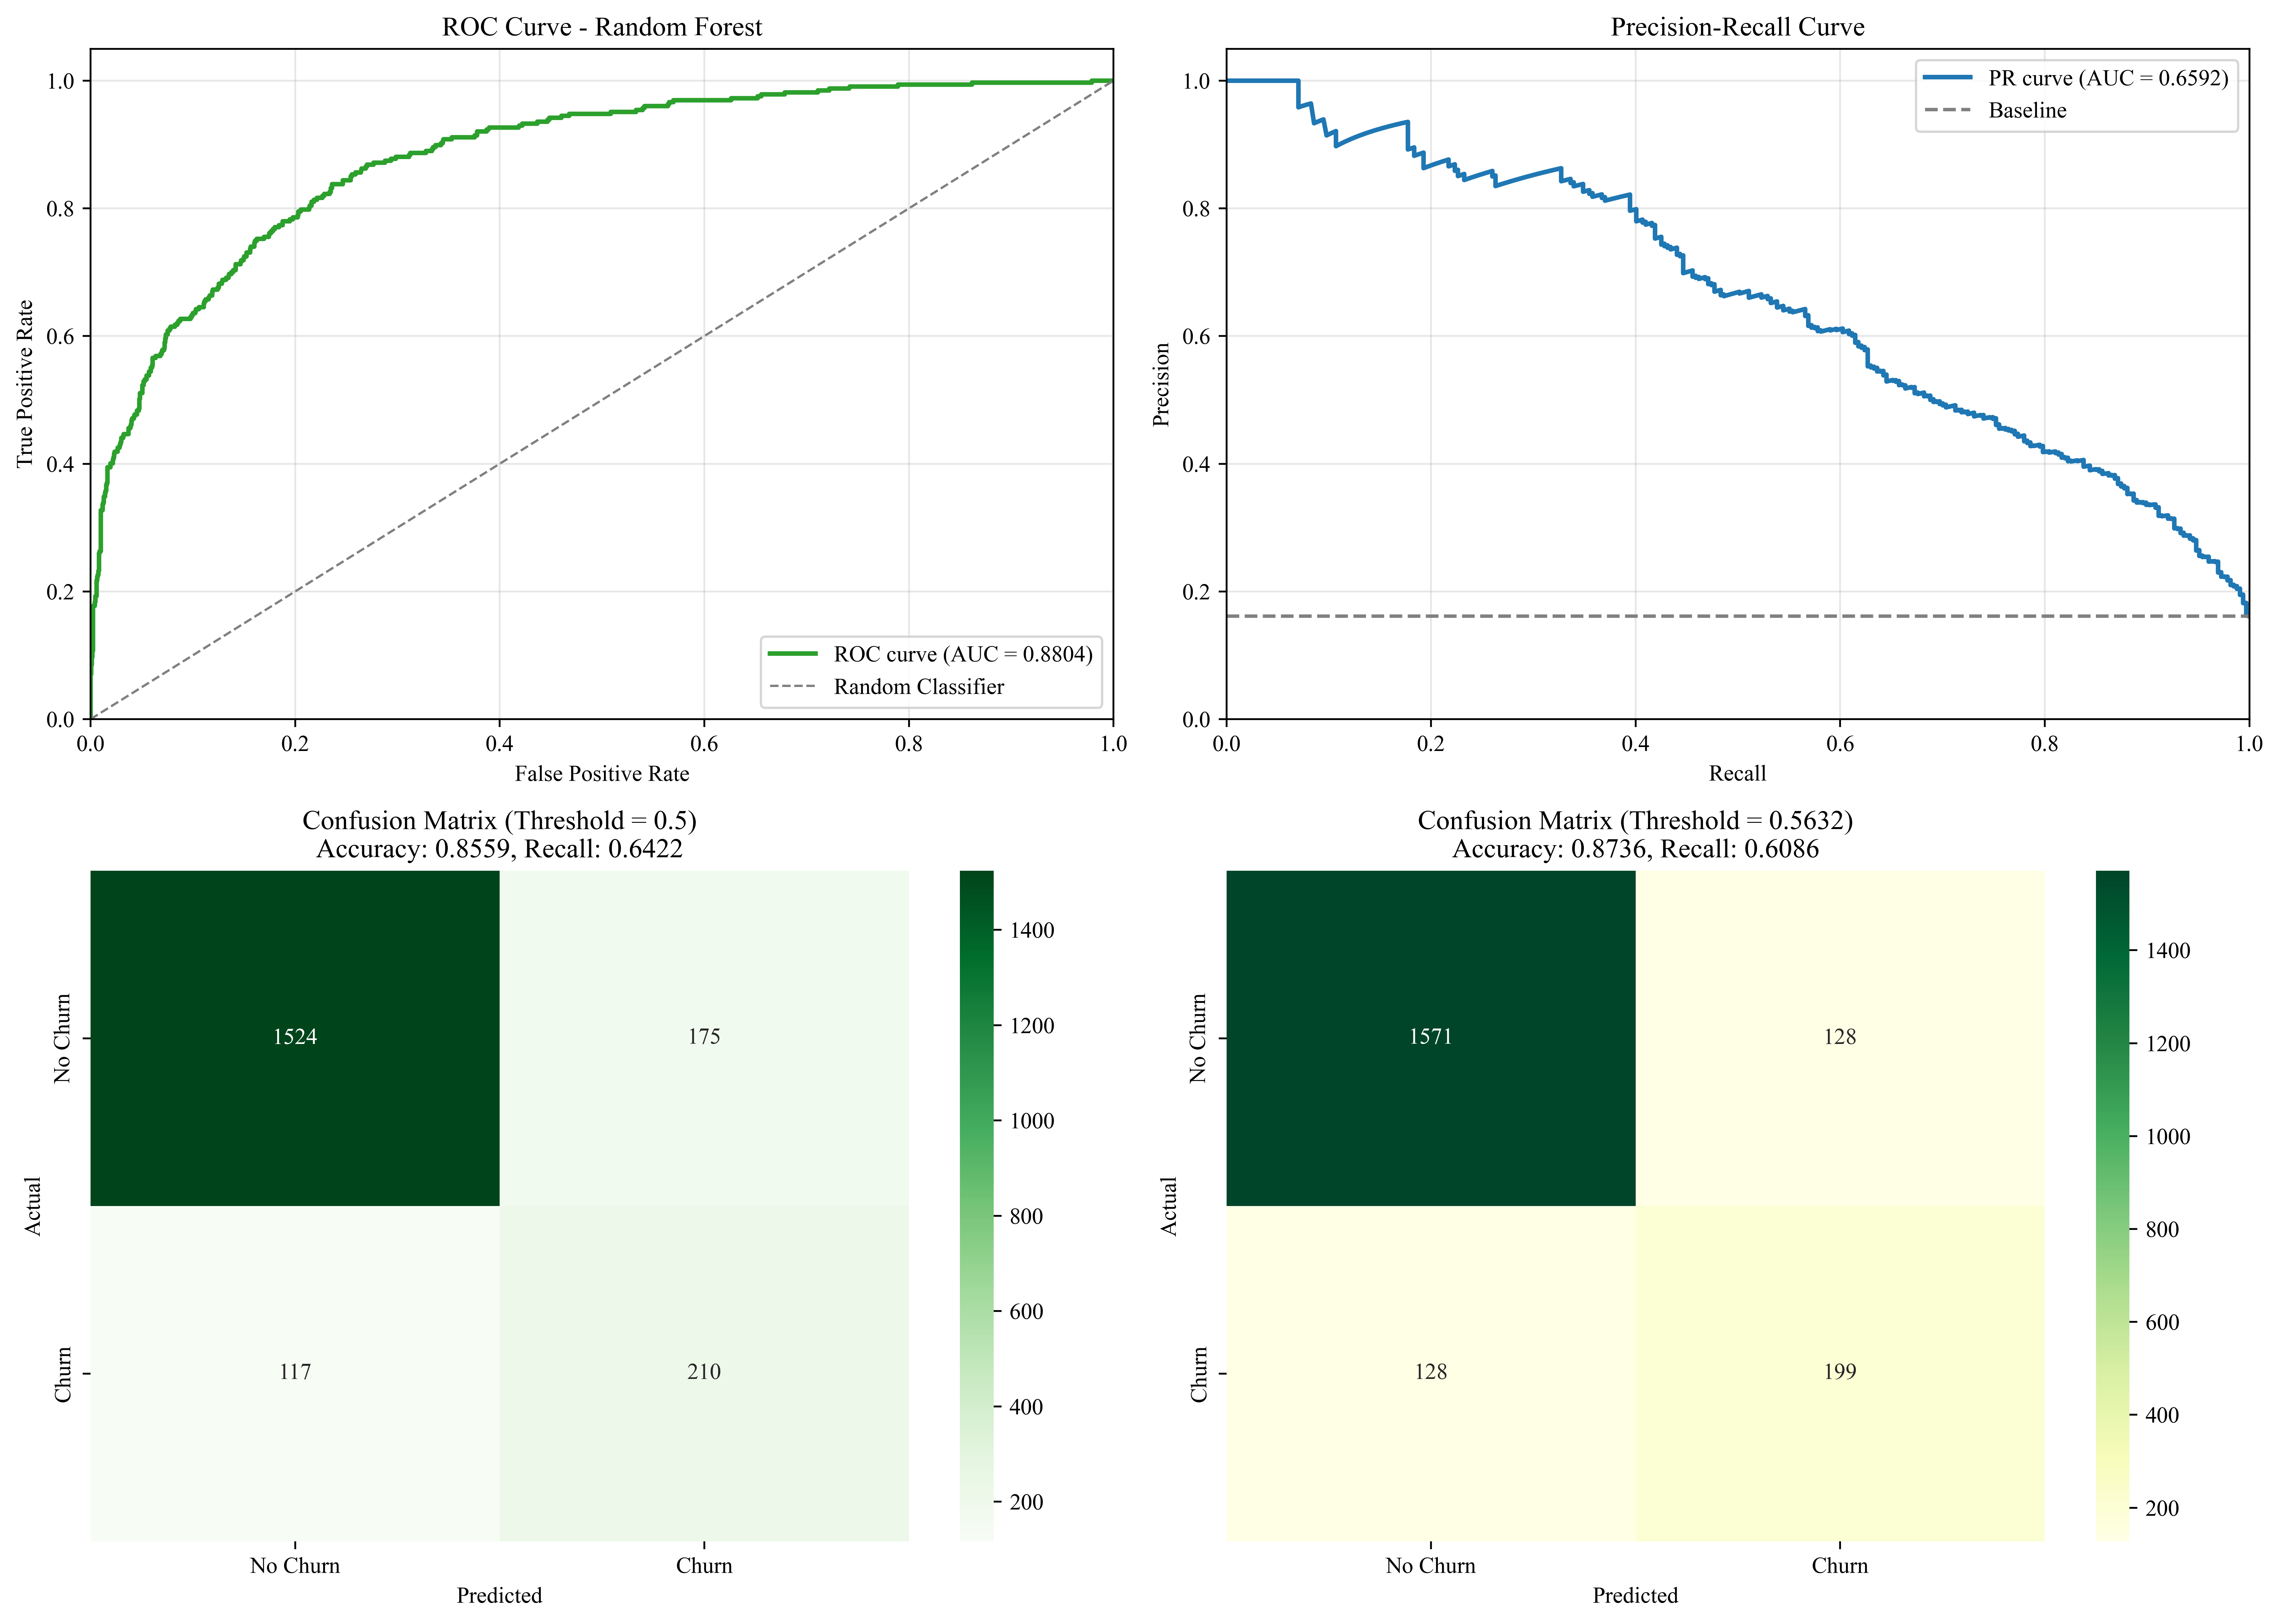

In [20]:
# BƯỚC 4: VẼ BIỂU ĐỒ ROC-AUC VÀ PRECISION-RECALL CURVE
print("\n" + "="*70)
print("BƯỚC 4: BIỂU ĐỒ ĐÁNH GIÁ MÔ HÌNH - RANDOM FOREST")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=500)

# 1. ROC Curve
fpr_rf, tpr_rf, roc_thresholds_rf = roc_curve(y_test, y_pred_proba_best_rf)
roc_auc_rf_plot = auc(fpr_rf, tpr_rf)

axes[0, 0].plot(fpr_rf, tpr_rf, color='#2ca02c', lw=2, label=f'ROC curve (AUC = {roc_auc_rf_plot:.4f})')
axes[0, 0].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
axes[0, 0].set_xlim([0.0, 1.0])
axes[0, 0].set_ylim([0.0, 1.05])
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate')
axes[0, 0].set_title('ROC Curve - Random Forest')
axes[0, 0].legend(loc="lower right")
axes[0, 0].grid(alpha=0.3)

# 2. Precision-Recall Curve
precision_vals_rf, recall_vals_rf, _ = precision_recall_curve(y_test, y_pred_proba_best_rf)
pr_auc_rf = auc(recall_vals_rf, precision_vals_rf)

axes[0, 1].plot(recall_vals_rf, precision_vals_rf, color='#1f77b4', lw=2, label=f'PR curve (AUC = {pr_auc_rf:.4f})')
axes[0, 1].axhline(y=y_test.sum()/len(y_test), color='gray', linestyle='--', label='Baseline')
axes[0, 1].set_xlim([0.0, 1.0])
axes[0, 1].set_ylim([0.0, 1.05])
axes[0, 1].set_xlabel('Recall')
axes[0, 1].set_ylabel('Precision')
axes[0, 1].set_title('Precision-Recall Curve')
axes[0, 1].legend(loc="best")
axes[0, 1].grid(alpha=0.3)

# 3. Confusion Matrix - Mô hình gốc (threshold = 0.5)
cm_orig_rf = confusion_matrix(y_test, y_pred_best_rf)
sns.heatmap(cm_orig_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1, 0], 
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
axes[1, 0].set_title(f'Confusion Matrix (Threshold = 0.5)\nAccuracy: {accuracy_rf:.4f}, Recall: {recall_rf:.4f}')
axes[1, 0].set_ylabel('Actual')
axes[1, 0].set_xlabel('Predicted')

# 4. Confusion Matrix - Mô hình tuned (threshold tối ưu)
cm_tuned_rf = confusion_matrix(y_test, y_pred_tuned_rf)
sns.heatmap(cm_tuned_rf, annot=True, fmt='d', cmap='YlGn', ax=axes[1, 1],
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
axes[1, 1].set_title(f'Confusion Matrix (Threshold = {best_threshold_f1_rf:.4f})\nAccuracy: {accuracy_tuned_rf:.4f}, Recall: {recall_tuned_rf:.4f}')
axes[1, 1].set_ylabel('Actual')
axes[1, 1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()


In [21]:
# BƯỚC 5: SO SÁNH MÔ HÌNH TRƯỚC VÀ SAU KHI TUNING
print("\n" + "="*70)
print("BƯỚC 5: SO SÁNH MÔ HÌNH TRƯỚC VÀ SAU KHI TUNING - RANDOM FOREST")
print("="*70)

# Huấn luyện mô hình cơ bản để so sánh
basic_rf = RandomForestClassifier(random_state=42)
basic_rf.fit(X_resampled, y_resampled)
y_pred_basic_rf = basic_rf.predict(X_test)
y_pred_proba_basic_rf = basic_rf.predict_proba(X_test)[:, 1]

# Tính toán metrics cho mô hình cơ bản
basic_metrics_rf = {
    'Accuracy': accuracy_score(y_test, y_pred_basic_rf),
    'Precision': precision_score(y_test, y_pred_basic_rf),
    'Recall': recall_score(y_test, y_pred_basic_rf),
    'F1-Score': f1_score(y_test, y_pred_basic_rf),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_basic_rf)
}

# Tính toán metrics cho mô hình tuned
tuned_metrics_rf = {
    'Accuracy': accuracy_tuned_rf,
    'Precision': precision_tuned_rf,
    'Recall': recall_tuned_rf,
    'F1-Score': f1_tuned_rf,
    'ROC-AUC': roc_auc_rf
}

# Tạo DataFrame so sánh
comparison_df_rf = pd.DataFrame({
    'Basic Model': basic_metrics_rf,
    'Tuned Model': tuned_metrics_rf,
    'Improvement': {k: tuned_metrics_rf[k] - basic_metrics_rf[k] for k in basic_metrics_rf.keys()}
})

print("\nBảng so sánh:")
print(comparison_df_rf.to_string())

print("\n" + "="*70)
print("KẾT LUẬN TUNING - RANDOM FOREST:")
print("="*70)
for metric, improvement in comparison_df_rf['Improvement'].items():
    symbol = "↑" if improvement > 0 else "↓" if improvement < 0 else "→"
    print(f"  {metric}: {symbol} {improvement:+.4f}")



BƯỚC 5: SO SÁNH MÔ HÌNH TRƯỚC VÀ SAU KHI TUNING - RANDOM FOREST

Bảng so sánh:
           Basic Model  Tuned Model  Improvement
Accuracy      0.855380     0.873643     0.018263
Precision     0.548295     0.608563     0.060267
Recall        0.590214     0.608563     0.018349
F1-Score      0.568483     0.608563     0.040080
ROC-AUC       0.863747     0.880373     0.016626

KẾT LUẬN TUNING - RANDOM FOREST:
  Accuracy: ↑ +0.0183
  Precision: ↑ +0.0603
  Recall: ↑ +0.0183
  F1-Score: ↑ +0.0401
  ROC-AUC: ↑ +0.0166



BƯỚC 6: PHÂN TÍCH PHÂN PHỐI XÁC SUẤT DỰ ĐOÁN - RANDOM FOREST


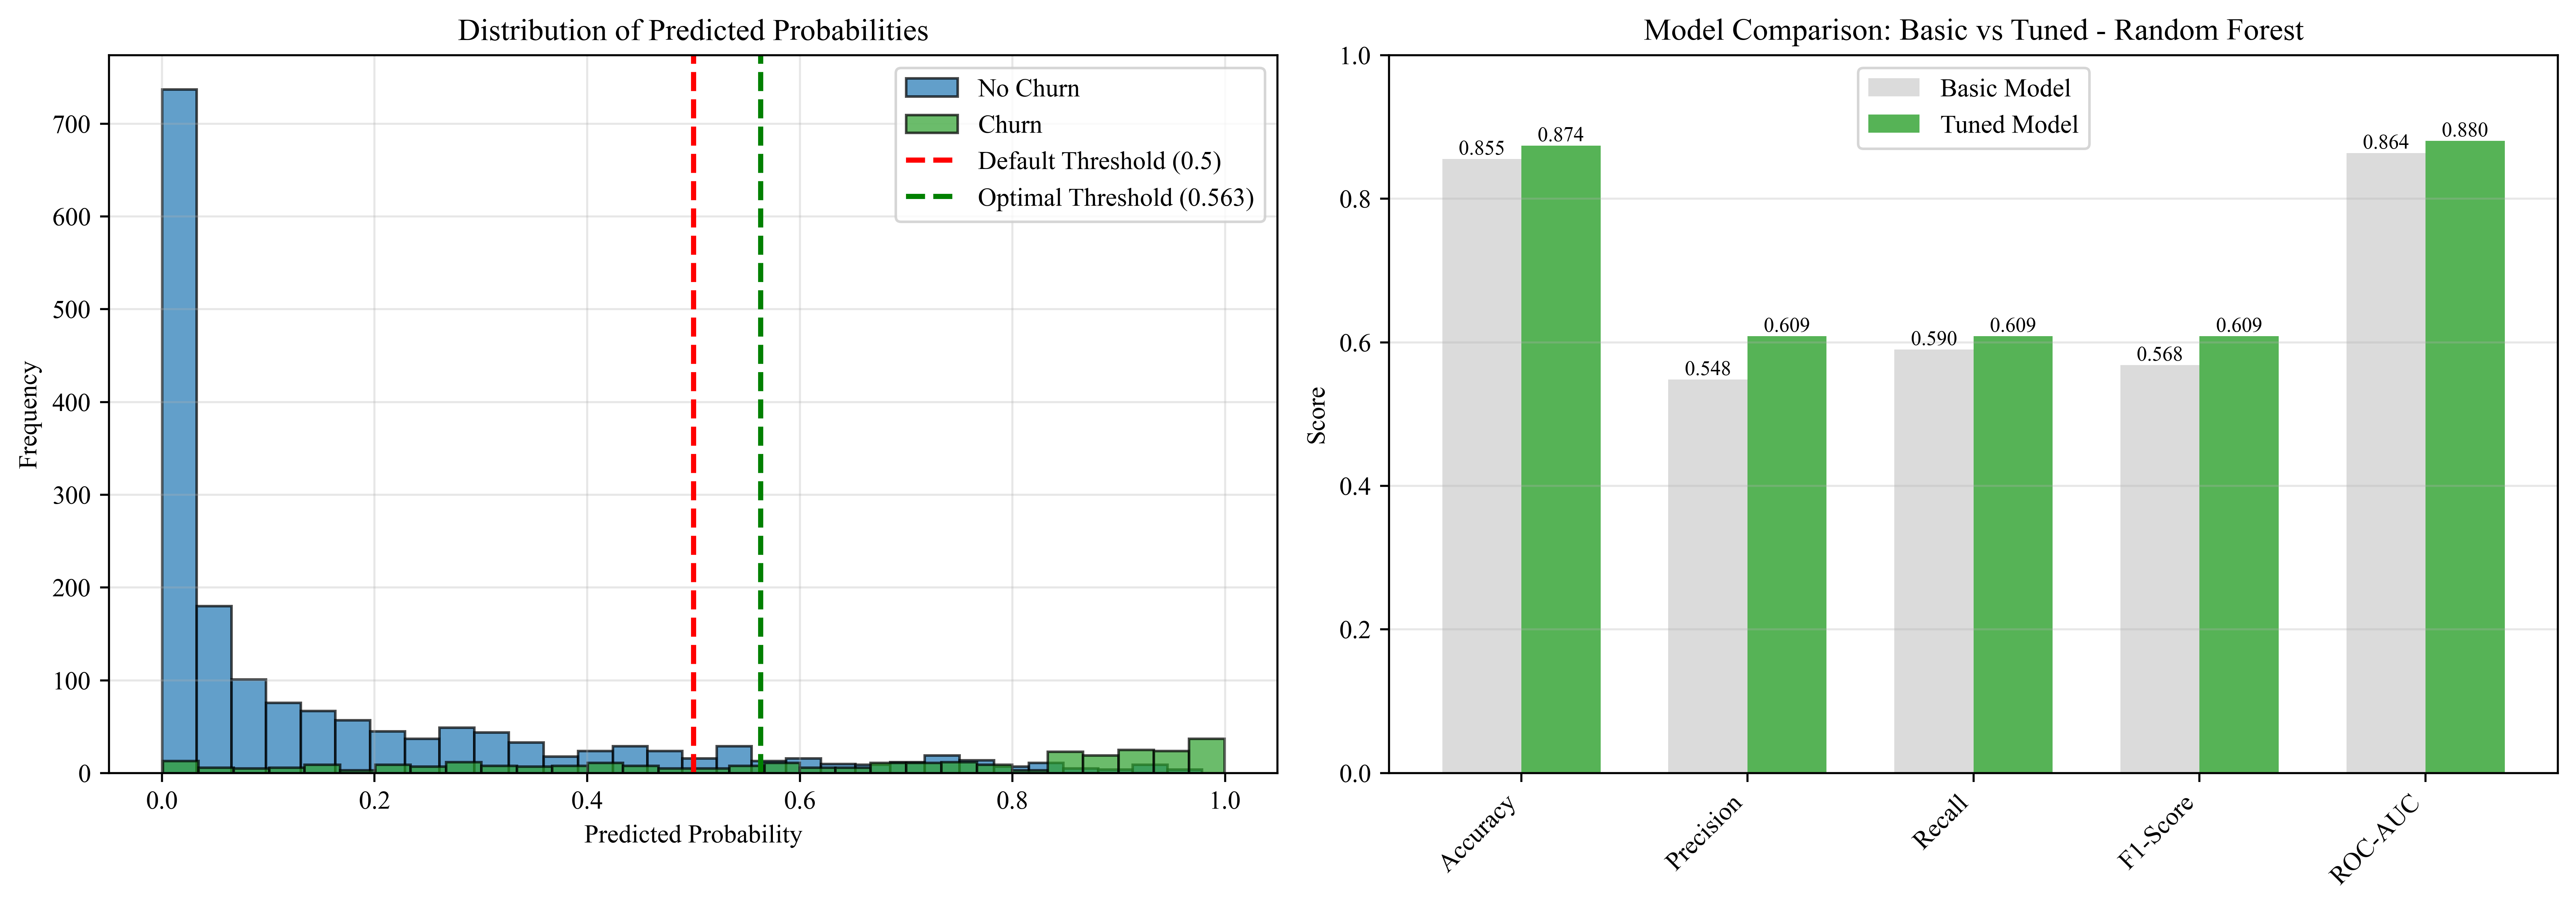


✓ Phân tích hoàn tất!


In [22]:
# BƯỚC 6: PHÂN TÍCH PHÂN PHỐI XÁC SUẤT DỰ ĐOÁN
print("\n" + "="*70)
print("BƯỚC 6: PHÂN TÍCH PHÂN PHỐI XÁC SUẤT DỰ ĐOÁN - RANDOM FOREST")
print("="*70)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=500)

# Phân phối xác suất cho lớp 0 (No Churn)
axes[0].hist(y_pred_proba_best_rf[y_test == 0], bins=30, alpha=0.7, 
             label='No Churn', color='#1f77b4', edgecolor='black')
# Phân phối xác suất cho lớp 1 (Churn)
axes[0].hist(y_pred_proba_best_rf[y_test == 1], bins=30, alpha=0.7, 
             label='Churn', color='#2ca02c', edgecolor='black')
axes[0].axvline(0.5, color='red', linestyle='--', linewidth=2, label='Default Threshold (0.5)')
axes[0].axvline(best_threshold_f1_rf, color='green', linestyle='--', linewidth=2, 
                label=f'Optimal Threshold ({best_threshold_f1_rf:.3f})')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Predicted Probabilities')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Biểu đồ cột so sánh metrics
metrics_names_rf = list(basic_metrics_rf.keys())
x_pos_rf = np.arange(len(metrics_names_rf))
width = 0.35

bars1 = axes[1].bar(x_pos_rf - width/2, [basic_metrics_rf[m] for m in metrics_names_rf], 
                    width, label='Basic Model', color='#d3d3d3', alpha=0.8)
bars2 = axes[1].bar(x_pos_rf + width/2, [tuned_metrics_rf[m] for m in metrics_names_rf], 
                    width, label='Tuned Model', color='#2ca02c', alpha=0.8)

axes[1].set_ylabel('Score')
axes[1].set_title('Model Comparison: Basic vs Tuned - Random Forest')
axes[1].set_xticks(x_pos_rf)
axes[1].set_xticklabels(metrics_names_rf, rotation=45, ha='right')
axes[1].legend()
axes[1].set_ylim([0, 1.0])
axes[1].grid(axis='y', alpha=0.3)

# Thêm giá trị trên các cột
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print("\n✓ Phân tích hoàn tất!")


Summary - Random Forest Model Tuning

**Các bước tuning thực hiện:**

1. **GridSearchCV**: Tìm best hyperparameters cho Random Forest bằng 5-fold cross-validation
2. **Threshold Optimization**: Tối ưu hóa classification threshold dựa trên F1-score
3. **Model Evaluation**: So sánh hiệu suất mô hình trước và sau tuning

**Hyperparameters được tuning:**
- `n_estimators`: Số lượng cây (50, 100, 200, 300)
- `max_depth`: Độ sâu tối đa của cây (10, 15, 20, None)
- `min_samples_split`: Số mẫu tối thiểu để split node (2, 5, 10)
- `min_samples_leaf`: Số mẫu tối thiểu ở leaf node (1, 2, 4)
- `max_features`: Số features xét khi split ('sqrt', 'log2')
- `class_weight`: Cân bằng class weight ('balanced', 'balanced_subsample', None)

**Kết quả tuning sẽ cho biết:**
- Best hyperparameters được chọn
- Cải thiện hiệu suất trên từng metric
- Optimal threshold cho classification

*Random Forest*
> **Accuracy** = 0.87

Mô hình dự đoán đúng 87% tổng số khách hàng trong tập dữ liệu, bao gồm cả khách hàng rời bỏ và không rời bỏ dịch vụ.

> **Precision** (Độ chuẩn xác trên lớp 1) = 0.61

Trong tất cả các khách hàng được mô hình dự đoán là rời bỏ dịch vụ (1), có 61% thực sự rời bỏ dịch vụ.
39% còn lại là những khách hàng không rời bỏ nhưng mô hình dự đoán là rời bỏ.

> **Recall** (Độ nhạy trên lớp 1) = 0.61

Trong tổng số khách hàng thực tế rời bỏ dịch vụ, mô hình phát hiện đúng 61%. 39% còn lại là khách hàng thực sự rời bỏ nhưng mô hình dự đoán là không phát hiện được.



<mark>Mặc dù Random Forest có độ chính xác tổng thể cao hơn, Logistic Regression được lựa chọn do có Recall cao hơn trên nhóm khách hàng rời bỏ. Điều này giúp giảm thiểu việc bỏ sót khách hàng có nguy cơ rời bỏ, từ đó phù hợp hơn với mục tiêu giữ chân khách hàng</mark>

In [23]:
df.head()

,User_ID,Age,Gender,Income_Category,is_income_unknown,User_Level,Usage_Duration,Services_Used,Months_Inactive,Total_Spending,...,Marital_Status_Married,Marital_Status_Single,Marital_Status_Unknown,Education_Level_Doctorate,Education_Level_Graduate,Education_Level_High School,Education_Level_Post-Graduate,Education_Level_Uneducated,Education_Level_Unknown,Churn
0,768805383,45,0,2.0,0,0,0.384621,0.763943,-1.327136,-0.959707,...,1,0,0,0,0,1,0,0,0,0
1,818770008,49,1,0.0,0,0,1.010715,1.407306,-1.327136,-0.916433,...,0,1,0,0,1,0,0,0,0,0
2,713982108,51,0,3.0,0,0,0.008965,0.120579,-1.327136,-0.740982,...,1,0,0,0,1,0,0,0,0,0
3,769911858,40,1,0.0,0,0,-0.241473,-0.522785,1.641478,-0.951758,...,0,0,1,0,0,1,0,0,0,0
4,709106358,40,0,2.0,0,0,-1.869317,0.763943,-1.327136,-1.056263,...,1,0,0,0,0,0,0,1,0,0
